In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load preprocessed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (736, 18)
X_test: (184, 18)
y_train: (736,)
y_test: (184,)


In [2]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        82
           1       0.84      0.85      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



In [3]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    class_weight='balanced',  # handles class imbalance
    random_state=42
)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, rf_pred))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



In [4]:
# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,       # number of trees
    learning_rate=0.1,      # how much each tree corrects the previous
    max_depth=4,            # how deep each tree can go
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Results:")
print(classification_report(y_test, xgb_pred))

XGBoost Results:
              precision    recall  f1-score   support

           0       0.83      0.78      0.81        82
           1       0.83      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



D:\heart-disease-prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:46:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [5]:
# Train SVM
svm_model = SVC(
    probability=True,        # needed to calculate AUC score later
    class_weight='balanced',
    random_state=42
)
svm_model.fit(X_train, y_train)

# Make predictions
svm_pred = svm_model.predict(X_test)

print("SVM Results:")
print(classification_report(y_test, svm_pred))

SVM Results:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



D:\heart-disease-prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [6]:
# Compare all models
models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    'SVM': svm_pred
}

print(f"{'Model':<25} {'Accuracy':>10} {'Recall (Disease)':>18} {'Precision (Disease)':>20} {'F1 (Disease)':>14}")
print("-" * 90)

for name, pred in models.items():
    from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred)
    pre = precision_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"{name:<25} {acc:>10.2%} {rec:>18.2%} {pre:>20.2%} {f1:>14.2%}")

Model                       Accuracy   Recall (Disease)  Precision (Disease)   F1 (Disease)
------------------------------------------------------------------------------------------
Logistic Regression           83.15%             85.29%               84.47%         84.88%
Random Forest                 84.78%             88.24%               84.91%         86.54%
XGBoost                       83.15%             87.25%               83.18%         85.17%
SVM                           84.78%             89.22%               84.26%         86.67%


In [7]:
# Save the best model
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(svm_model, '../models/best_model.joblib')
print("Best model (SVM) saved successfully!")

Best model (SVM) saved successfully!


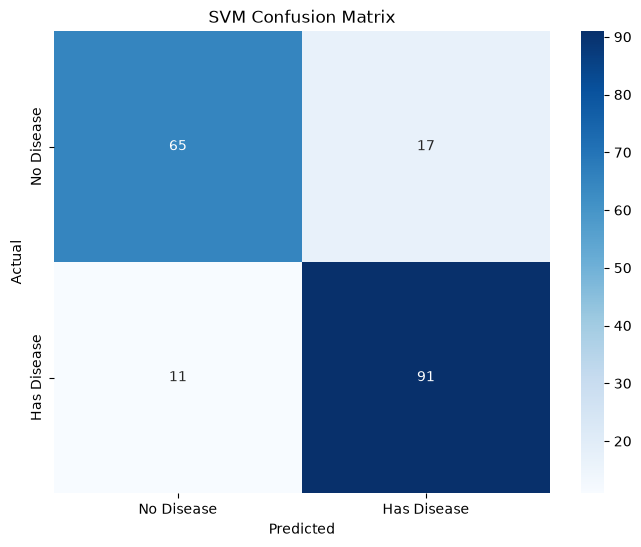

In [8]:
# Confusion Matrix for SVM
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()